# Cristiano Ronaldo Career Performance Analysis 

**Tools:** Python, Pandas, Matplotlib, Seaborn

This notebook performs exploratory data analysis on Cristiano Ronaldo's club and international career data.

**Dataset:** `Cristiano_Ronaldo_All_Data_Analysis.csv`


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('Cristiano_Ronaldo_All_Data_Analysis.csv')
df.head()


,Data_Type,Season,Year,Club,Team,Country,Country_or_National_Team,Competition,Competition_Name,Age,Appearances,Minutes,Goals,Assists,Goal_Involvements,Penalties_Scored,Yellow_Cards,Red_Cards,Goals_per_90,Assists_per_90,Goal_Involvement_per_90,Start_Year,Career_Phase
0,Club,2002-03,2002,Sporting CP,Sporting CP,Portugal,Portugal,Primeira Liga,Primeira Liga,17,25,1080.0,3,3,6.0,0.0,1.0,0.0,0.25,0.25,0.50,2002,Early Manchester United
1,Club,2003-04,2003,Manchester United,Manchester United,England,England,Premier League,Premier League,18,29,1555.0,4,4,8.0,0.0,5.0,1.0,0.23,0.23,0.46,2003,Early Manchester United
2,International,2003,2003,NaN,Portugal,NaN,Portugal,International,International,19,2,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003,NaN
3,Club,2004-05,2004,Manchester United,Manchester United,England,England,Premier League,Premier League,19,33,2423.0,5,4,9.0,0.0,3.0,0.0,0.19,0.15,0.33,2004,Early Manchester United
4,International,2004,2004,NaN,Portugal,NaN,Portugal,International,International,19,16,NaN,7,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004,NaN


## 1. Dataset Overview

In [4]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print('\nData Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())


Rows: 51
Columns: 23

Data Types:
Data_Type                       str
Season                          str
Year                            str
Club                            str
Team                            str
Country                         str
Country_or_National_Team        str
Competition                     str
Competition_Name                str
Age                           int64
Appearances                   int64
Minutes                     float64
Goals                         int64
Assists                       int64
Goal_Involvements           float64
Penalties_Scored            float64
Yellow_Cards                float64
Red_Cards                   float64
Goals_per_90                float64
Assists_per_90              float64
Goal_Involvement_per_90     float64
Start_Year                    int64
Career_Phase                    str
dtype: object

Missing Values:
Data_Type                    0
Season                       0
Year                         0
Club          

In [5]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Data_Type,51,2,Club,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,51,49,2021-22,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,51,26,2021,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Club,27,5,Real Madrid,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Team,51,6,Portugal,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,27,5,Spain,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country_or_National_Team,51,5,Portugal,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Competition,51,6,International,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Competition_Name,51,6,International,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,51.0,NaN,NaN,NaN,29.54902,7.11706,17.0,23.5,30.0,36.0,41.0


## 2. Club vs International Performance

In [6]:
performance_summary = df.groupby('Data_Type')[['Appearances','Goals','Assists']].sum()
performance_summary


,Appearances,Goals,Assists
Data_Type,,,
Club,764,604,156
International,245,147,32


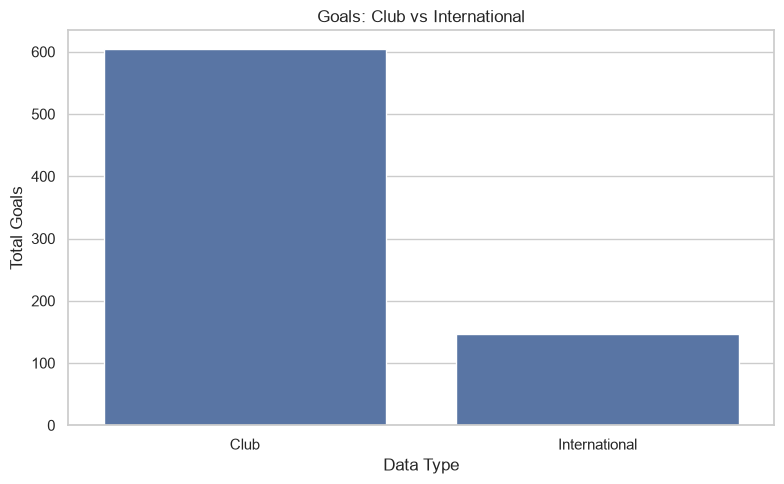

In [7]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Data_Type', y='Goals', estimator='sum', errorbar=None)
plt.title('Goals: Club vs International')
plt.xlabel('Data Type')
plt.ylabel('Total Goals')
plt.tight_layout()
plt.show()


## 3. Club Career Analysis

In [8]:
club_df = df[df['Data_Type'] == 'Club'].copy()
club_df[['Appearances','Goals','Assists','Minutes']] = club_df[['Appearances','Goals','Assists','Minutes']].apply(pd.to_numeric, errors='coerce')
club_df.groupby('Club')[['Appearances','Goals','Assists','Minutes']].sum().sort_values('Goals', ascending=False)


,Appearances,Goals,Assists,Minutes
Club,,,,
Real Madrid,292,311,83,25082.0
Al-Nassr,113,106,18,9731.0
Manchester United,236,103,37,17515.0
Juventus,98,81,15,8438.0
Sporting CP,25,3,3,1080.0


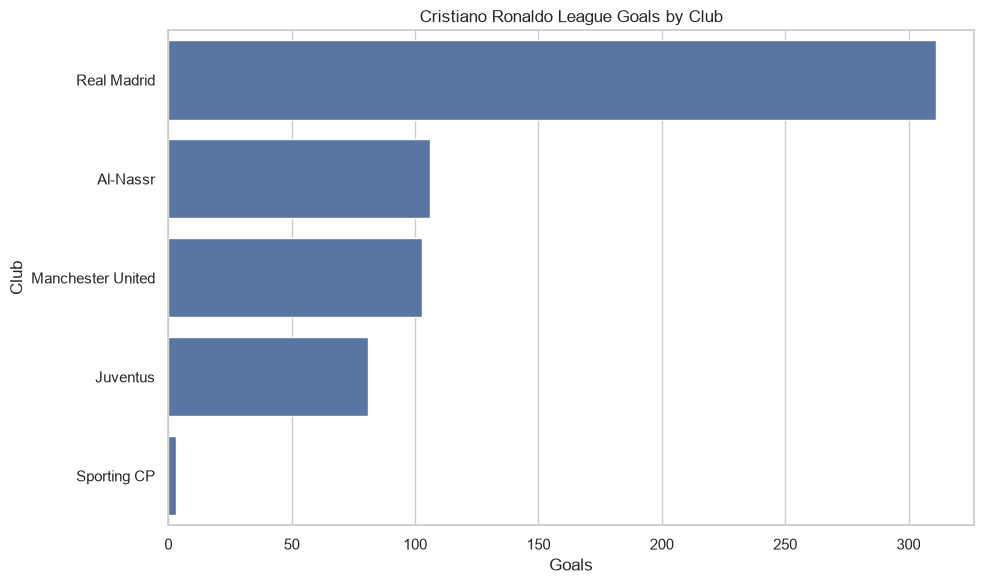

In [9]:
club_totals = club_df.groupby('Club', as_index=False)[['Goals','Assists','Appearances']].sum()
plt.figure(figsize=(10,6))
sns.barplot(data=club_totals.sort_values('Goals', ascending=False), x='Goals', y='Club', errorbar=None)
plt.title('Cristiano Ronaldo League Goals by Club')
plt.xlabel('Goals')
plt.ylabel('Club')
plt.tight_layout()
plt.show()


## 4. Goals by Season

In [10]:
season_df = club_df.groupby(['Season','Club'], as_index=False)[['Goals','Assists','Appearances']].sum()
season_df


,Season,Club,Goals,Assists,Appearances
0,2002-03,Sporting CP,3,3,25
1,2003-04,Manchester United,4,4,29
2,2004-05,Manchester United,5,4,33
3,2005-06,Manchester United,9,6,33
4,2006-07,Manchester United,17,8,34
5,2007-08,Manchester United,31,6,34
6,2008-09,Manchester United,18,6,33
7,2009-10,Real Madrid,26,7,29
8,2010-11,Real Madrid,40,9,34
9,2011-12,Real Madrid,46,12,38


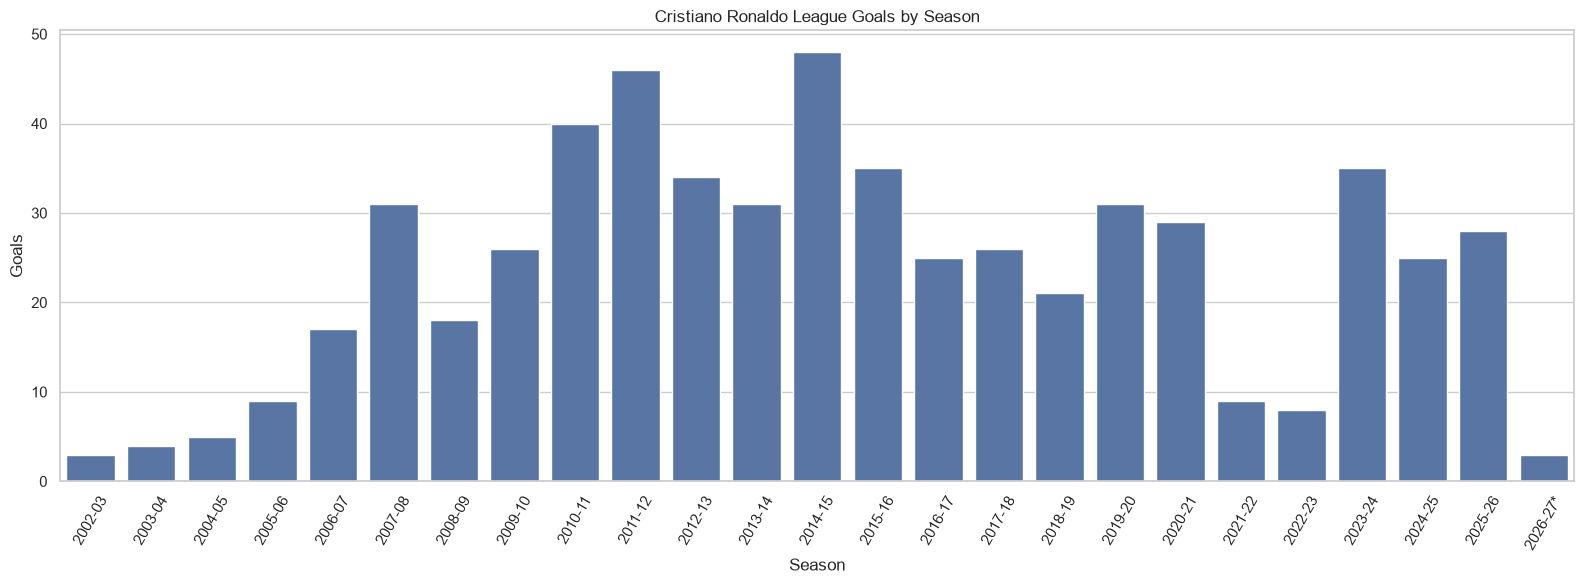

In [11]:
plt.figure(figsize=(16,6))
sns.barplot(data=season_df, x='Season', y='Goals', errorbar=None)
plt.title('Cristiano Ronaldo League Goals by Season')
plt.xlabel('Season')
plt.ylabel('Goals')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


## 5. Goals and Assists Trend

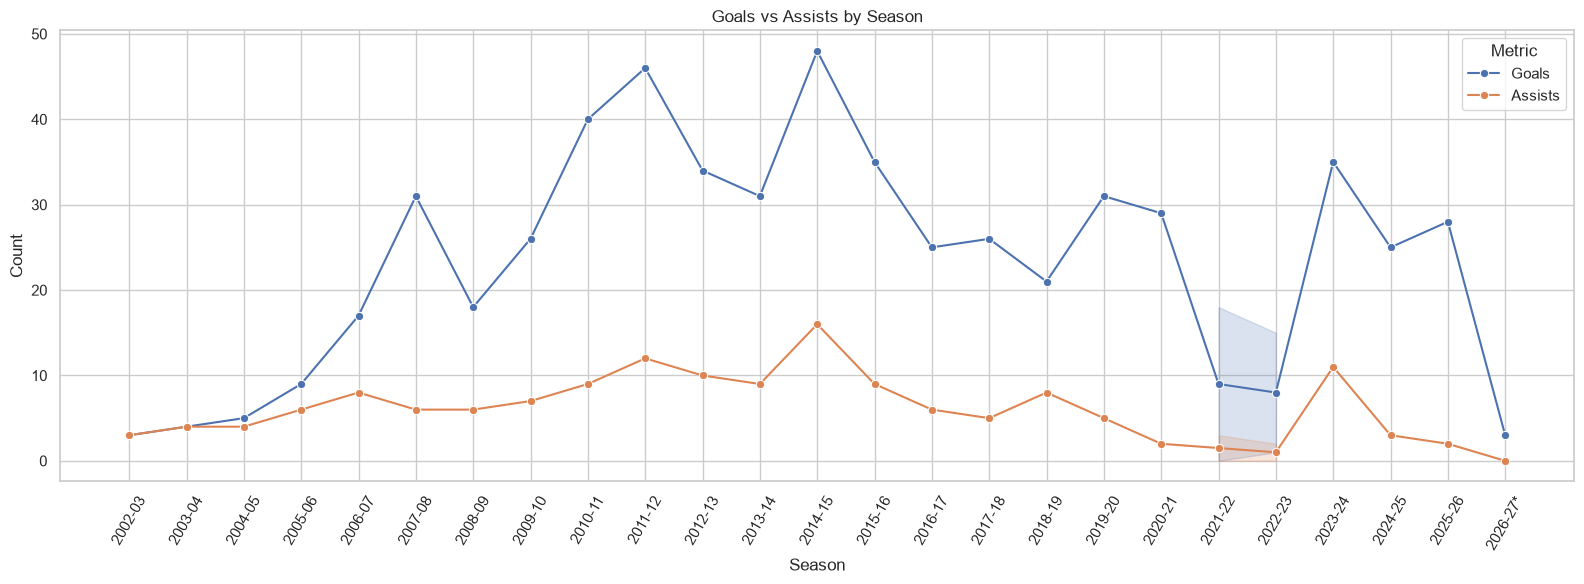

In [12]:
trend = season_df.melt(id_vars=['Season'], value_vars=['Goals','Assists'], var_name='Metric', value_name='Value')
plt.figure(figsize=(16,6))
sns.lineplot(data=trend, x='Season', y='Value', hue='Metric', marker='o')
plt.title('Goals vs Assists by Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


## 6. Peak Scoring Seasons

In [13]:
club_df.nlargest(10, 'Goals')[['Season','Club','Age','Appearances','Goals','Assists','Goal_Involvements','Goals_per_90']]


,Season,Club,Age,Appearances,Goals,Assists,Goal_Involvements,Goals_per_90
23,2014-15,Real Madrid,29,35,48,16,64.0,1.39
17,2011-12,Real Madrid,26,38,46,12,58.0,1.24
15,2010-11,Real Madrid,25,34,40,9,49.0,1.24
25,2015-16,Real Madrid,30,36,35,9,44.0,0.99
43,2023-24,Al-Nassr,38,31,35,11,46.0,1.19
19,2012-13,Real Madrid,27,34,34,10,44.0,1.13
9,2007-08,Manchester United,22,34,31,6,37.0,1.02
21,2013-14,Real Madrid,28,30,31,9,40.0,1.10
33,2019-20,Juventus,34,33,31,5,36.0,0.96
35,2020-21,Juventus,35,33,29,2,31.0,0.93


## 7. Age vs Performance

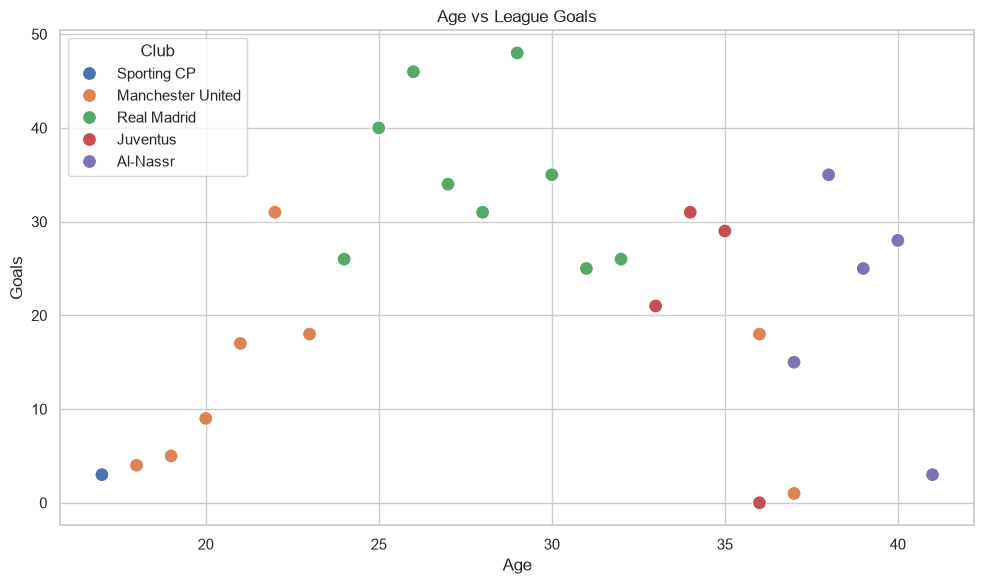

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=club_df, x='Age', y='Goals', hue='Club', s=100)
plt.title('Age vs League Goals')
plt.xlabel('Age')
plt.ylabel('Goals')
plt.tight_layout()
plt.show()


## 8. Goals per 90

In [15]:
club_rates = club_df.groupby('Club', as_index=False).agg({'Goals':'sum','Minutes':'sum'})
club_rates['Goals_per_90_Calculated'] = club_rates['Goals'] / (club_rates['Minutes'] / 90)
club_rates.sort_values('Goals_per_90_Calculated', ascending=False)


,Club,Goals,Minutes,Goals_per_90_Calculated
3,Real Madrid,311,25082.0,1.115940
0,Al-Nassr,106,9731.0,0.980372
1,Juventus,81,8438.0,0.863949
2,Manchester United,103,17515.0,0.529261
4,Sporting CP,3,1080.0,0.250000


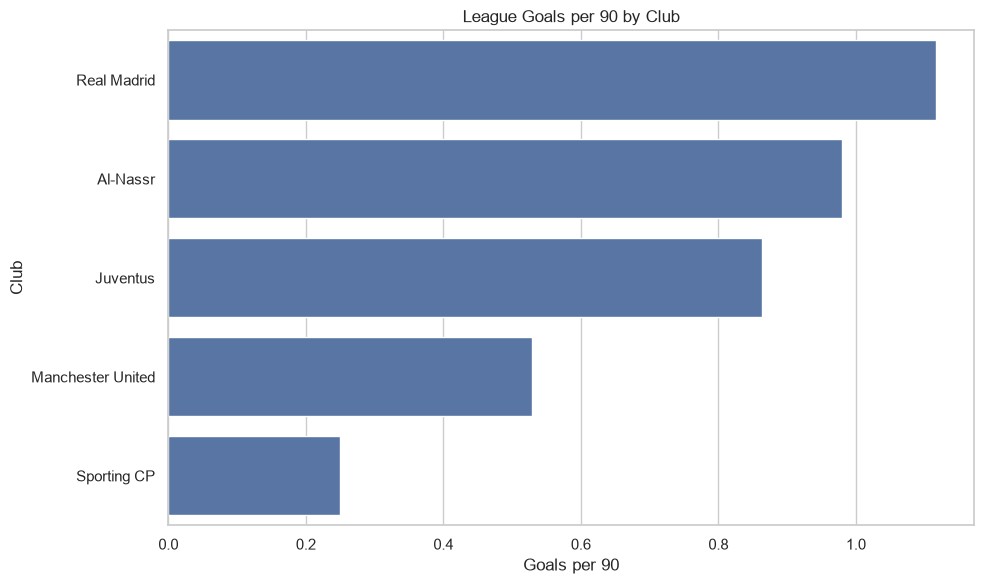

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(data=club_rates.sort_values('Goals_per_90_Calculated', ascending=False), x='Goals_per_90_Calculated', y='Club', errorbar=None)
plt.title('League Goals per 90 by Club')
plt.xlabel('Goals per 90')
plt.ylabel('Club')
plt.tight_layout()
plt.show()


## 9. Correlation Analysis

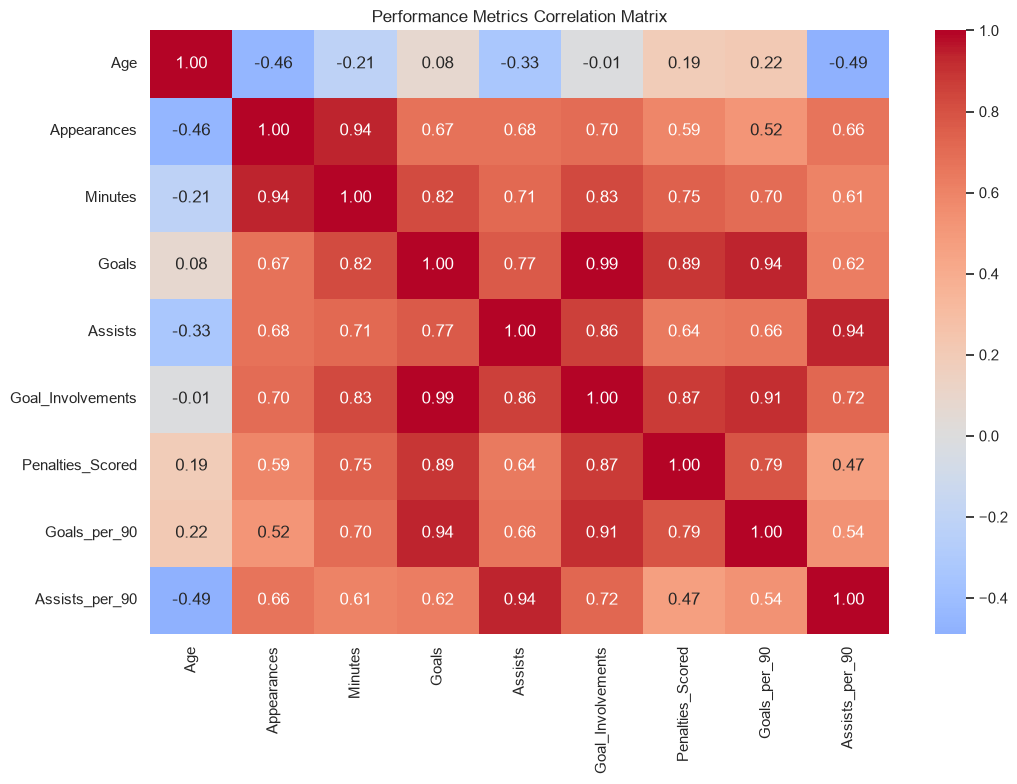

In [17]:
numeric_cols = ['Age','Appearances','Minutes','Goals','Assists','Goal_Involvements','Penalties_Scored','Goals_per_90','Assists_per_90']
corr = club_df[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(11,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Performance Metrics Correlation Matrix')
plt.tight_layout()
plt.show()


## 10. Penalty Contribution

In [18]:
penalty_df = club_df.groupby('Club', as_index=False)[['Goals','Penalties_Scored']].sum()
penalty_df['Penalty_Goal_Percentage'] = (penalty_df['Penalties_Scored'] / penalty_df['Goals'] * 100).round(2)
penalty_df.sort_values('Penalty_Goal_Percentage', ascending=False)


,Club,Goals,Penalties_Scored,Penalty_Goal_Percentage
1,Juventus,81,23.0,28.40
0,Al-Nassr,106,22.0,20.75
3,Real Madrid,311,61.0,19.61
2,Manchester United,103,14.0,13.59
4,Sporting CP,3,0.0,0.00


## 11. Career Phase Analysis

In [19]:
phase = club_df.groupby('Career_Phase', observed=True)[['Appearances','Minutes','Goals','Assists','Goal_Involvements']].sum()
phase


,Appearances,Minutes,Goals,Assists,Goal_Involvements
Career_Phase,,,,,
Al-Nassr Era,97,8298.0,91,16,107.0
Early Manchester United,221,15614.0,87,37,124.0
Juventus / Manchester United Return,123,10164.0,94,12,106.0
Real Madrid Peak,323,27770.0,332,91,423.0


## 12. Key Research Questions

- Which season had the highest league goal output?
- Which club period produced the highest league goal contribution?
- How did goals per 90 change across Ronaldo's career?
- How did scoring output change with age?
- What relationship exists between appearances, minutes, goals and assists?
- How significant were penalties in his league scoring?
- How does his international output compare with his club output?


## Conclusion

Use the results from the analysis above to summarize Ronaldo's career performance using evidence from the dataset. Avoid treating the current partial season as a completed season when interpreting trends.


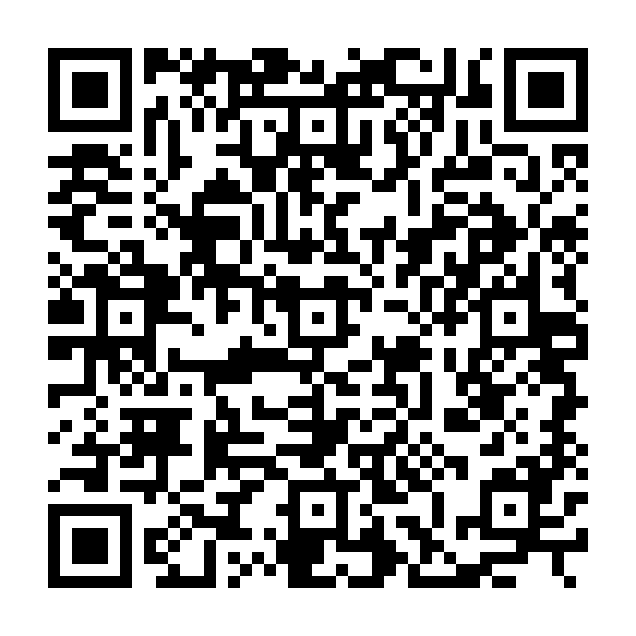

QR code generated successfully!
Saved to: E:\games_ext\FDVA_EXP_NO_1_QR.png


In [22]:
import qrcode
from IPython.display import display

url = "https://github.com/vijay2git/FDVA-VJ/tree/main/EXP%20NO%201"

qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_H,
    box_size=12,
    border=4
)

qr.add_data(url)
qr.make(fit=True)

img = qr.make_image(fill_color="black", back_color="white")

output_path = r"E:\games_ext\FDVA_EXP_NO_1_QR.png"
img.save(output_path)

display(img)

print("QR code generated successfully!")
print("Saved to:", output_path)